
# Aula 2 - Modbus RTU/TCP e prática no TIA Portal V17


## Fontes usadas como base

- Modbus.org, `modbusprotocolspecification.pdf`: especificação do protocolo Modbus Application Protocol V1.1b3; usada para PDU, ADU, modelo de dados, endereçamento, function codes e respostas de exceção.
- Hu et al., `A survey of intrusion detection on industrial control systems.pdf`: usada para contextualizar ICS, requisitos de segurança, protocolos industriais e IDS.
- Mitchell e Chen, `A Survey of Intrusion Detection Techniquesfor Cyber-Physical Systems.pdf`: usada para contextualizar CPS, SCADA, legado, baixa latência, monitoramento de processos físicos e desafios de IDS.
- Alanazi, Mahmood e Chowdhury, **SCADA vulnerabilities and attacks: A review of the state-of-the-art and open issues**, *Computers & Security*, vol. 125, 103028, 2023: usada para introduzir componentes SCADA, gerações de arquitetura SCADA, comparação entre requisitos ICS/IT e protocolos SCADA.
- Documentação Siemens, Entry-ID 102020340: exemplo oficial de Modbus/TCP com `MB_CLIENT` e `MB_SERVER` para S7-1200/S7-1500.


## Pré-requisitos

Antes da prática, é importante que a turma tenha uma noção básica de:
- endereço IP, porta TCP e rede local;
- CLP, IHM, sensor, atuador, inversor e gateway;
- leitura e escrita de variáveis em um CLP;
- diferença entre bit, byte, word e registrador de 16 bits;
- uso básico do TIA Portal para criar projeto, adicionar CPU e criar blocos.

Para a parte prática, o cenário padrão da aula considera dois equipamentos ou dois papéis lógicos:
- um CLP atuando como **Modbus TCP client** com `MB_CLIENT`;
- um CLP atuando como **Modbus TCP server** com `MB_SERVER`.

Se houver apenas um CLP físico, a prática pode ser adaptada para um simulador Modbus TCP no computador, mantendo os mesmos conceitos de IP, porta, endereço e registradores.


## 1. Introdução: por que começar por SCADA

Antes de estudar Modbus, é importante entender o ambiente onde ele normalmente aparece. Em automação industrial, Modbus não é um fim em si mesmo; ele é um meio para que componentes de um sistema **SCADA - Supervisory Control and Data Acquisition** troquem dados.

SCADA pode ser entendido como uma arquitetura usada para supervisionar, coletar dados e controlar processos industriais por meio de componentes distribuídos.

Em termos práticos, um SCADA conecta o mundo físico ao operador:

```text
Processo físico -> sensores/atuadores -> PLC/RTU -> rede industrial -> SCADA/HMI -> operador
```

Exemplos de processos supervisionados por SCADA:
- estações de tratamento de água;
- subestações de energia;
- linhas de produção;
- sistemas de bombeamento;
- plantas de óleo e gás;
- infraestrutura de transporte.

Nesse contexto, protocolos industriais têm uma função operacional direta. Eles carregam leituras, estados, comandos e parâmetros. Um registrador Modbus pode representar uma temperatura, um setpoint, um contador, uma permissão de partida ou um comando de escrita. Por isso, entender o frame Modbus é também entender uma parte da operação do processo.



## 2. Componentes principais de um SCADA

Um sistema SCADA pode ser entendido por funções. Para a aula, a organização mais útil é separar o sistema em quatro blocos: supervisão, aquisição de dados, troca de dados e armazenamento.

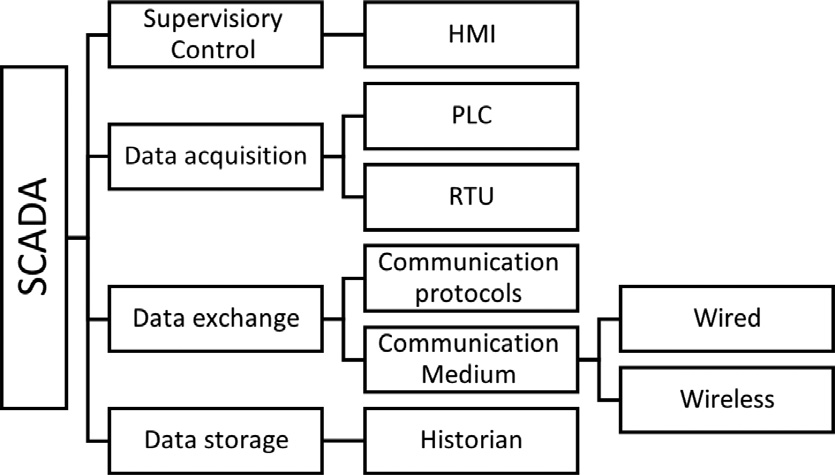

A figura organiza os componentes de forma funcional: a supervisão fica associada à HMI, a aquisição de dados fica associada a PLCs e RTUs, a troca de dados depende de protocolos e meios de comunicação, e o armazenamento fica associado ao historian.

| Função | Componentes comuns | Papel no sistema |
|---|---|---|
| Supervisão | HMI, MTU | permitir que o operador visualize estados, alarmes e comandos |
| Aquisição de dados | PLC, RTU, IED | coletar sinais do campo e executar controle local |
| Armazenamento | Historian, banco SQL | guardar dados históricos com marca temporal |
| Troca de dados | protocolos industriais e meio de comunicação | transportar leituras, comandos e eventos entre os componentes |

### HMI

A **HMI - Human-Machine Interface** é a interface do operador. Ela mostra telas, alarmes, tendências, estados de motores, válvulas, sensores e permite comandos autorizados.

### MTU

A **MTU - Master Terminal Unit** é uma unidade supervisória central. Em arquiteturas SCADA, ela coordena a comunicação com dispositivos de campo, como RTUs, e concentra dados para a operação.

### PLC

O **PLC - Programmable Logic Controller** é o controlador local. Ele lê entradas, executa a lógica de controle e atualiza saídas. Esse ciclo é conhecido como varredura ou scan:

1. ler entradas;
2. executar o programa;
3. atualizar saídas.

### RTU

A **RTU - Remote Terminal Unit** é muito usada em áreas geograficamente distribuídas. Ela também faz interface com sensores e atuadores, mas costuma ser mais associada a comunicações remotas, enlaces WAN, rádio, celular ou outros meios de longa distância.

### Historian

O **historian** armazena dados do processo ao longo do tempo. Ele permite responder perguntas como: quando a pressão subiu? quanto tempo a bomba ficou ligada? qual era a temperatura antes do alarme?

### Protocolos

Os protocolos industriais fazem a troca de dados. É aqui que entra o Modbus: ele define como um equipamento pede uma leitura ou uma escrita, e como o outro equipamento responde.


## 3. Evolução das arquiteturas SCADA

A segurança em SCADA mudou muito porque a arquitetura mudou. Sistemas que antes eram isolados passaram a se conectar a redes Ethernet, IP, nuvem e IoT.

| Geração | Característica principal | Vantagem | Limitação ou risco |
|---|---|---|---|
| Monolítica | mainframes e RTUs, ambiente isolado | menor exposição externa | cara, pouco escalável, dependente de fornecedor |
| Distribuída | estações distribuídas em LAN e RTUs via WAN | mais redundância e menor custo | ainda muito dependente de protocolos proprietários |
| Em rede | Ethernet, IP e sistemas comerciais | maior interoperabilidade e expansão | maior superfície de ataque |
| IoT/Cloud SCADA | integração com IoT, nuvem e big data | escalabilidade e acesso remoto | exposição a ataques de rede e dependência de controles de segurança |

### Arquitetura monolítica

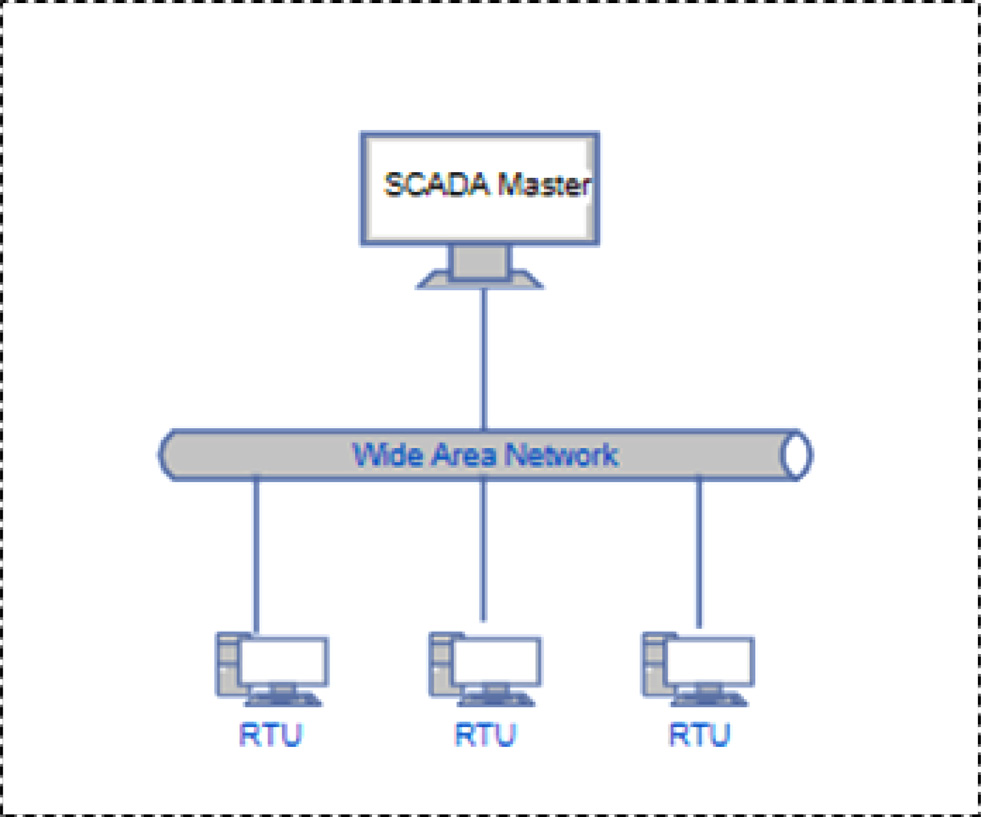

Na arquitetura monolítica, o controle fica concentrado em um sistema mestre, com RTUs conectadas por uma rede de longa distância. O ambiente tende a ser mais isolado, mas caro e pouco flexível.

### Arquitetura distribuída

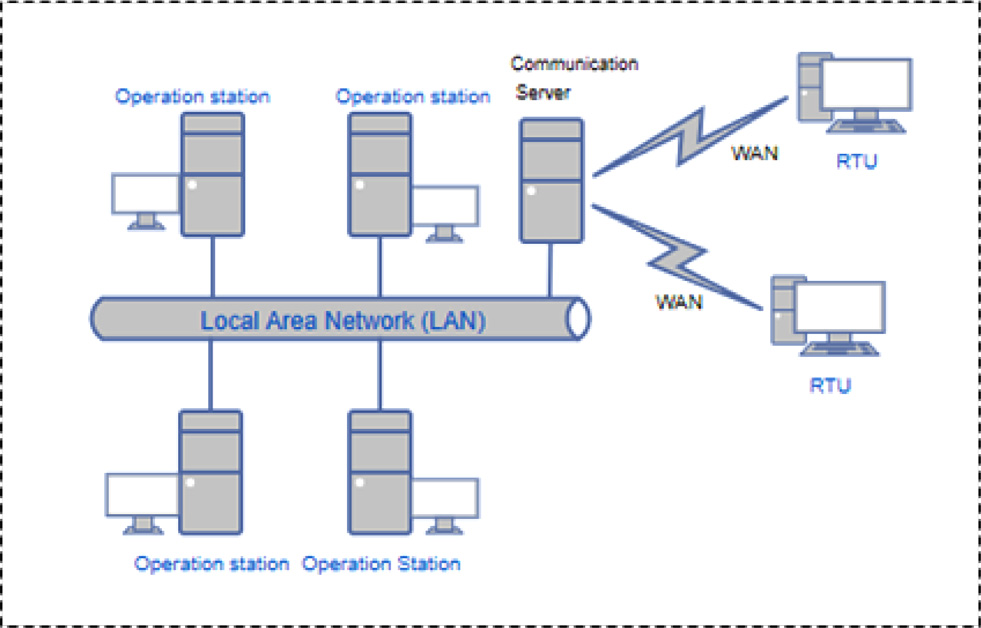

Na arquitetura distribuída, as estações de operação e o servidor de comunicação passam a compartilhar dados por LAN, enquanto RTUs continuam acessadas por enlaces WAN. A redundância melhora, mas a dependência de protocolos e soluções proprietárias ainda é forte.

### Arquitetura em rede

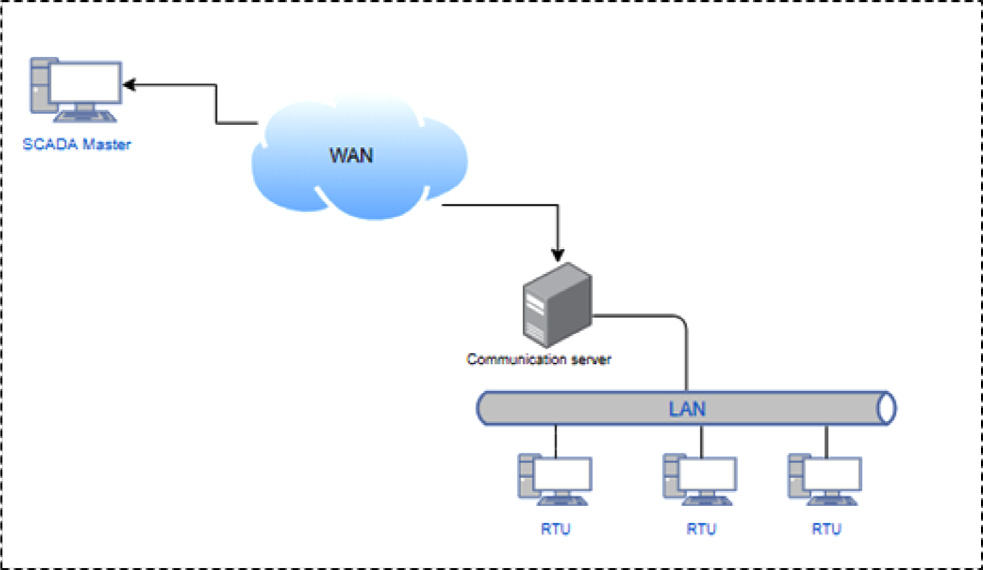

Na arquitetura em rede, IP, Ethernet e sistemas comerciais ganham espaço. Isso melhora interoperabilidade e escalabilidade, mas aumenta a superfície de ataque porque mais componentes passam a se comunicar por redes padronizadas.

### Arquitetura IoT/Cloud SCADA


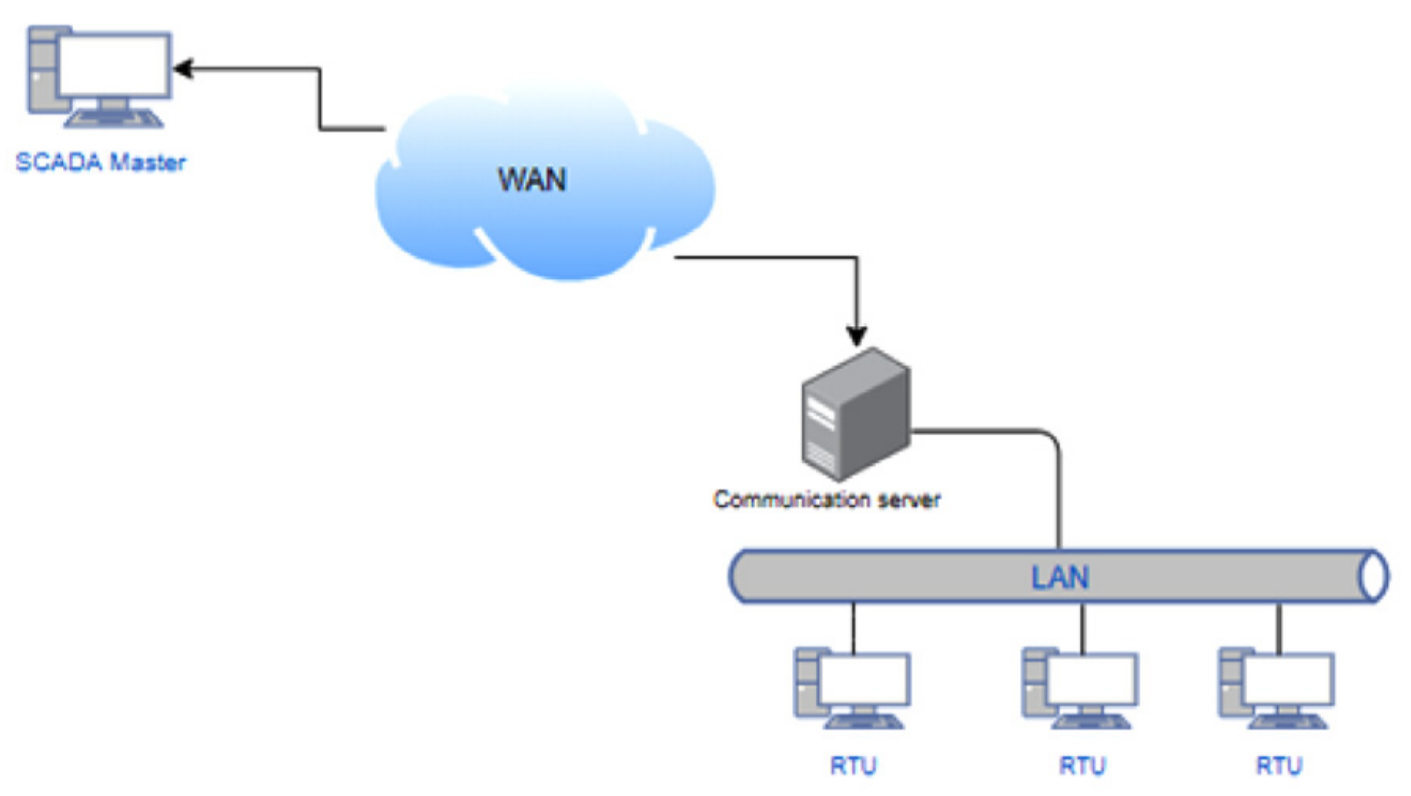

Na arquitetura IoT e Cloud SCADA, sensores e dispositivos de campo podem se conectar diretamente à nuvem, enviando dados por protocolos de IoT (como MQTT) ou utilizando gateways. Isso permite maior escalabilidade, análise de big data e acesso remoto de qualquer lugar, mas introduz novos desafios de segurança, exigindo criptografia e autenticação robustas para proteger os dados em trânsito e na nuvem.

A tendência histórica foi clara: SCADA ficou mais barato, escalável, flexível e conectado. O custo disso foi o aumento da exposição a ameaças.

Essa evolução explica por que protocolos simples e antigos, como Modbus, continuam importantes. Eles nasceram em um contexto de redes fechadas, mas hoje muitas vezes trafegam em redes IP conectadas a outros ambientes.


## 4. Protocolos de comunicação em SCADA

Os protocolos SCADA existem para permitir troca de dados entre MTUs, HMIs, PLCs, RTUs, IEDs, gateways e servidores. Com o crescimento das redes industriais, a interoperabilidade virou uma necessidade: equipamentos de fabricantes diferentes precisam conversar.

| Protocolo | Uso comum | Característica importante | Observação de segurança |
|---|---|---|---|
| Modbus RTU | PLCs/RTUs em RS-485/RS-232 | simples, aberto, mestre/escravo | usa CRC, mas não fornece autenticação ou criptografia |
| Modbus TCP/IP | CLPs, gateways, SCADA em Ethernet | cliente/servidor sobre TCP/IP | usa porta 502 e herda integridade das camadas inferiores, mas não autentica comandos |
| Profibus | automação industrial | mestre/escravo, muito usado em campo | depende da configuração e do ambiente |
| DNP3 | energia, água, óleo e gás | eventos, fragmentação e timestamp em alguns usos | versões antigas podem ter autenticação insuficiente |
| IEC 61850 | subestações elétricas | comunicação lógica e mensagens GOOSE | exige projeto cuidadoso de rede e segurança |
| IEC 60870 | sistemas elétricos distribuídos | controle remoto e telemetria | pode carecer de autenticação em implementações legadas |

Nesta aula, o foco será o Modbus porque ele é simples, comum em laboratório e aparece tanto em redes legadas quanto em redes Ethernet modernas.


## 5. Onde o Modbus entra em redes industriais

Redes industriais conectam equipamentos que participam diretamente do processo físico: CLPs, IHMs, remotas de I/O, inversores, sensores inteligentes, medidores, relés, gateways e supervisórios. Diferente de uma rede corporativa comum, uma falha de comunicação industrial pode afetar produção, segurança operacional e continuidade do processo.

Em uma arquitetura industrial moderna, é comum encontrar camadas como:

| Camada | Exemplos | Papel |
|---|---|---|
| Campo | sensores, atuadores, I/O remoto, inversores | medir e atuar no processo |
| Controle | CLP, RTU, IED | executar lógica de controle |
| Supervisão | IHM, SCADA, historian | visualizar, registrar e comandar |
| Gestão | MES, ERP, servidores | planejar e integrar a produção |

O Modbus aparece principalmente entre a camada de campo, controle e supervisão. Ele é usado para ler estados, escrever comandos e trocar valores numéricos entre dispositivos de fabricantes diferentes.


## 6. Por que o Modbus ainda importa

O Modbus foi criado em 1979 e continua sendo muito usado porque resolve um problema prático: permitir que equipamentos industriais troquem dados de forma simples e previsível.

Motivos para ainda aparecer em campo:
- **simplicidade**: poucas estruturas de dados e poucos comandos principais;
- **interoperabilidade**: muitos fabricantes implementam Modbus;
- **legado**: existem plantas com equipamentos antigos que ainda precisam operar;
- **facilidade de teste**: é relativamente simples capturar e interpretar pacotes;
- **gateways**: muitos conversores fazem ponte entre Modbus RTU, Modbus TCP e outros protocolos.

Essa simplicidade também cria um ponto crítico: o Modbus original não foi projetado com autenticação, criptografia ou autorização forte. Em uma rede aberta ou mal segmentada, um atacante pode tentar ler variáveis, escrever registradores ou repetir comandos válidos.


## 7. Modbus como protocolo de aplicação

A especificação define o Modbus como um protocolo de mensagens da camada de aplicação. A ideia central é simples: um dispositivo solicita uma operação e outro responde.

Na terminologia atual, usamos:
- **client**: inicia a requisição;
- **server**: responde é requisição.

Em muitos materiais antigos também aparecem os termos:
- **master**: equivalente ao client;
- **slave**: equivalente ao server.

Exemplo mental:
- o supervisório pergunta ao CLP: `qual é o valor dos holding registers a partir do endereço 10?`;
- o CLP responde com os valores;
- o supervisório pode também escrever um novo setpoint em um registrador permitido.


## 8. Modbus RTU vs Modbus TCP

Modbus RTU e Modbus TCP carregam a mesma ideia de aplicação, mas usam meios de transporte diferentes.

| Característica | Modbus RTU | Modbus TCP |
|---|---|---|
| Meio comum | RS-485 ou RS-232 | Ethernet TCP/IP |
| Modelo físico | barramento serial | rede Ethernet com switch |
| Identificação do destino | endereço do escravo/server | IP, porta TCP e Unit ID |
| Porta padrão | não se aplica | TCP 502 |
| Verificação no frame | CRC | TCP/IP jé trata integridade de transporte; Modbus TCP usa MBAP |
| Uso comum | dispositivos de campo e redes legadas | CLPs, gateways, SCADA, medidores Ethernet |

Na prática, muitos ambientes misturam os dois: um supervisório ou CLP fala Modbus TCP com um gateway, e o gateway fala Modbus RTU em RS-485 com vários dispositivos de campo.


## 9. PDU e ADU

A especificação separa duas ideias importantes:

- **PDU - Protocol Data Unit**: parte comum do protocolo Modbus, independente do meio físico.
- **ADU - Application Data Unit**: mensagem completa no meio de comunicação escolhido.
  
  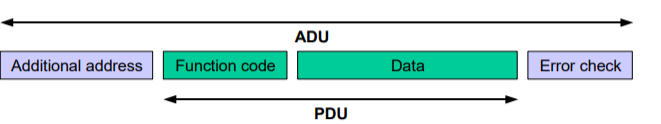

A PDU possui:

| Campo | Tamanho | Função |
|---|---:|---|
| Function code | 1 byte | indica a operação solicitada |
| Data | n bytes | parâmetros da operação ou dados retornados |

A ADU muda conforme o transporte:

| Variante | Estrutura simplificada |
|---|---|
| Modbus RTU | endereço do server + PDU + CRC |
| Modbus TCP | cabeçalho MBAP + PDU |

Limites importantes da especificação:
- PDU Modbus: até **253 bytes**;
- ADU Modbus RTU: até **256 bytes**;
- ADU Modbus TCP: até **260 bytes**, considerando MBAP de 7 bytes.


## 10. Ordem dos bytes: big-endian

O Modbus transmite endereços e valores numéricos de mais de 1 byte em **big-endian**: o byte mais significativo vem primeiro.

Exemplo:

| Valor de 16 bits | Byte transmitido primeiro | Byte transmitido depois |
|---|---|---|
| `0x1234` | `0x12` | `0x34` |

Isso é importante quando o aluno começa a interpretar pacotes no Wireshark ou quando valores `Word`, `Int`, `Real` e `DWord` precisam ser mapeados para registradores. Um registrador Modbus possui 16 bits; tipos maiores ocupam mais de um registrador e podem exigir cuidado com a ordem das words usada pelo fabricante.


## 11. Frame Modbus RTU

No Modbus RTU, a mensagem carrega o endereço do dispositivo no barramento e termina com CRC.

| Campo | Tamanho | Exemplo | Observação |
|---|---:|---|---|
| Server address | 1 byte | `01` | identifica o dispositivo no barramento serial |
| Function code | 1 byte | `03` | leitura de holding registers |
| Data | n bytes | `00 00 00 02` | endereço inicial e quantidade, por exemplo |
| CRC | 2 bytes | varia | detecção de erro no frame RTU |

Exemplo de requisição RTU para ler 2 holding registers a partir do endereço PDU 0:

```text
01 03 00 00 00 02 CRC_LO CRC_HI
```

| Server address | Function code | Starting address Hi | Starting address Lo | Quantity Hi | Quantity Lo | CRC Lo | CRC Hi |
|---|---|---|---|---|---|---|---|
| `01` | `03` | `00` | `00` | `00` | `02` | `CRC_LO` | `CRC_HI` |


Leitura do exemplo:
- `01`: endereço do server no barramento;
- `03`: function code Read Holding Registers;
- `00 00`: endereço inicial;
- `00 02`: quantidade de registradores;
- `CRC_LO CRC_HI`: verificação do frame RTU.


## 12. Frame Modbus TCP e cabeçalho MBAP

No Modbus TCP, a mensagem usa TCP/IP e recebe um cabeçalho chamado **MBAP - Modbus Application Protocol Header**.

| Campo MBAP | Tamanho | Função |
|---|---:|---|
| Transaction ID | 2 bytes | associa requisição e resposta |
| Protocol ID | 2 bytes | normalmente `0x0000` para Modbus |
| Length | 2 bytes | quantidade de bytes restantes: Unit ID + PDU |
| Unit ID | 1 byte | identifica unidade lógica, útil principalmente com gateways |

Depois do MBAP vem a PDU:

```text
MBAP: Transaction ID | Protocol ID | Length | Unit ID
PDU : Function code  | Data
```

Exemplo de requisição Modbus TCP para ler 2 holding registers a partir do endereço PDU 0:

```text
00 01 00 00 00 06 01 03 00 00 00 02
```

| Transaction ID Hi | Transaction ID Lo | Protocol ID Hi | Protocol ID Lo | Length Hi | Length Lo | Unit ID | Function code | Starting address Hi | Starting address Lo | Quantity Hi | Quantity Lo |
|---|---|---|---|---|---|---|---|---|---|---|---|
| `00` | `01` | `00` | `00` | `00` | `06` | `01` | `03` | `00` | `00` | `00` | `02` |


Leitura do exemplo:
- `00 01`: Transaction ID;
- `00 00`: Protocol ID Modbus;
- `00 06`: 6 bytes restantes;
- `01`: Unit ID;
- `03`: Read Holding Registers;
- `00 00`: endereço inicial;
- `00 02`: quantidade de registradores.


## 13. Modelo de dados Modbus: o que são as tabelas Modbus

Quando a especificação fala em **tabelas Modbus**, ela não está falando de uma tabela SQL, planilha ou tabela visual do TIA Portal. Ela está falando de quatro **áreas lógicas de dados** que o protocolo enxerga no server.

Essas tabelas são uma camada de abstração. O client pergunta por uma posição dessa tabela, e o server decide internamente de onde aquele valor vem.

| Tabela Modbus | Tipo de item | Acesso pelo protocolo | Exemplo industrial |
|---|---|---|---|
| Discrete Inputs | 1 bit | somente leitura | estado de sensor digital, fim de curso, proteção atuada |
| Coils | 1 bit | leitura e escrita | comando liga/desliga, permissivo, bit de controle |
| Input Registers | 16 bits | somente leitura | medição analógica, corrente, tensão, temperatura |
| Holding Registers | 16 bits | leitura e escrita | setpoint, parâmetro, contador, comando numérico |

A tabela Modbus é o que o **protocolo expõe para fora**. A memória real do CLP é como o **programa guarda isso por dentro**.

Exemplo conceitual:

| Visão do client Modbus | Visão interna do CLP server |
|---|---|
| Holding register 0 | `DB_HoldingRegisters.holdingRegister[0]` |
| Holding register 1 | `DB_HoldingRegisters.holdingRegister[1]` |
| Holding register 2 | `DB_HoldingRegisters.holdingRegister[2]` |
| Coil 0 | um bit de comando dentro de um DB ou memória interna |
| Input register 0 | valor tratado a partir de uma entrada analógica |

Isso quer dizer que o Modbus não obriga o CLP a ter uma área física chamada "holding register". O que ele exige é que o server consiga responder quando alguém pedir um holding register em determinado endereço PDU.

Para a prática no TIA Portal, o foco será em **holding registers**, porque eles permitem leitura e escrita e são muito usados para testar `MB_CLIENT` e `MB_SERVER`.


## 14. Relação entre tabela Modbus e memória do CLP

A relação entre Modbus e memória do CLP é uma relação de **mapeamento**.

O pacote Modbus não carrega o nome da variável do CLP. Ele não diz `Motor1_Setpoint`, `DB10.DBW0` ou `holdingRegister[3]`. Ele carrega apenas campos padronizados, como function code, endereço PDU e quantidade. O programa do server é quem liga esse endereço Modbus a uma área real de dados.

Um jeito didático de visualizar:

```text
Client Modbus
   envia: FC3, starting address 0, quantity 4

Server Modbus no CLP
   interpreta: ler holding registers 0, 1, 2 e 3

Programa/DB do CLP
   entrega: DB_HoldingRegisters.holdingRegister[0..3]
```

No TIA Portal, esse mapeamento normalmente é feito apontando o `dataBuffer` do `MB_SERVER` para uma área de dados, por exemplo um array em um DB global:

```text
DB_HoldingRegisters
holdingRegister : Array[0..99] of Word
```

Nesse caso, podemos adotar o seguinte mapa:

| Endereço PDU Modbus | Referência comum | Variável no DB do CLP | Tamanho |
|---:|---|---|---:|
| 0 | `40001` | `holdingRegister[0]` | 16 bits |
| 1 | `40002` | `holdingRegister[1]` | 16 bits |
| 2 | `40003` | `holdingRegister[2]` | 16 bits |
| 10 | `40011` | `holdingRegister[10]` | 16 bits |

O mesmo raciocínio vale para outros tipos de área:

| Dado do processo | Como poderia aparecer no CLP | Como poderia ser exposto em Modbus |
|---|---|---|
| temperatura medida | valor tratado em um DB | Input register 0 |
| setpoint de temperatura | variável `Word` ou `Int` em DB | Holding register 0 |
| comando ligar bomba | bit booleano em DB | Coil 0 |
| sensor de porta aberta | entrada digital ou bit tratado | Discrete input 0 |

Ponto importante: o endereço Modbus não precisa ser igual ao endereço físico ou simbólico do CLP. O projetista define o mapa. Por isso, em uma planta real, a documentação mais importante é o **mapa Modbus** do equipamento: ele diz o que existe em cada endereço, qual tipo de dado é usado, se pode escrever e qual escala deve ser aplicada.

Exemplo de escala: um sensor pode enviar `253` em um holding register, mas o manual dizer que o valor real é `25,3 °C`, porque existe fator de escala 10. O Modbus transporta o número bruto; a interpretação de engenharia vem do mapa do fabricante ou do projeto.


## 15. O que é endereço PDU e para que serve

O **endereço PDU** é o endereço que realmente aparece dentro da mensagem Modbus. Ele não é, necessariamente, o nome da variável no CLP, nem o endereço físico de memória do processador. Ele é o **índice lógico usado pelo protocolo** para dizer ao server qual item da tabela Modbus deve ser acessado.

Pense no Modbus como uma interface padronizada entre equipamentos. O client não precisa saber se o server guarda o dado em um DB, em uma marca `M`, em uma entrada analógica, em uma estrutura interna ou em uma memória de firmware. O client só envia:
- qual tipo de dado quer acessar, definido pelo function code;
- a partir de qual endereço PDU quer começar;
- quantos itens consecutivos quer ler ou escrever.

Exemplo em `FC3 - Read Holding Registers`:

| Parte da requisição | Exemplo | Papel |
|---|---|---|
| Function code | `03` | seleciona a tabela de holding registers para leitura |
| Starting address | `00 00` | começa no endereço PDU 0 |
| Quantity | `00 02` | lê 2 registradores consecutivos |

A PDU fica assim:

```text
03 00 00 00 02
```

Leitura da PDU:
- `03`: operação de leitura de holding registers;
- `00 00`: endereço PDU inicial 0;
- `00 02`: quantidade 2.

Então, o significado prático é: **leia os holding registers 0 e 1 do server**.

Atenção: o endereço PDU normalmente começa em zero. Já muitos manuais mostram referências comerciais como `40001`, `40002`, `40003`. Nesse caso, a relação comum é:

| Referência no manual | Endereço PDU enviado na mensagem |
|---|---:|
| `40001` | 0 |
| `40002` | 1 |
| `40003` | 2 |
| `40010` | 9 |

Por isso, quando você configura uma comunicação no TIA Portal ou interpreta um pacote no Wireshark, a pergunta correta é: **qual endereço PDU o pacote está usando?** Depois você verifica como esse endereço PDU foi mapeado para a memória real do CLP ou do equipamento.


## 16. Endereçamento: referências `00001`, `10001`, `30001`, `40001` e endereço PDU

Em Modbus, existem duas formas de falar sobre endereços, e elas costumam ser misturadas em manuais:

1. **Referência Modbus de documentação**, como `00001`, `10001`, `30001` e `40001`.
2. **Endereço PDU**, que é o valor numérico enviado dentro do pacote Modbus.

As referências `00001`, `10001`, `30001` e `40001` são uma convenção histórica de documentação, muito associada ao padrão Modicon. Elas servem para humanos identificarem rapidamente **qual tabela Modbus** está sendo usada.

A ideia é que o primeiro algarismo indique o tipo de área, e os demais indiquem a posição do item dentro daquela área.

| Referência de documentação | Tabela Modbus | Tipo de dado | Acesso comum | Function codes associados | Endereço PDU do primeiro item |
|---|---|---|---|---|---:|
| `00001` | Coils | bit | leitura e escrita | `01`, `05`, `15` | 0 |
| `10001` | Discrete Inputs | bit | somente leitura | `02` | 0 |
| `30001` | Input Registers | word de 16 bits | somente leitura | `04` | 0 |
| `40001` | Holding Registers | word de 16 bits | leitura e escrita | `03`, `06`, `16` | 0 |

Por exemplo:
- `00001` significa primeira coil, acessada na PDU como endereço `0`;
- `10001` significa primeiro discrete input, acessado na PDU como endereço `0`;
- `30001` significa primeiro input register, acessado na PDU como endereço `0`;
- `40001` significa primeiro holding register, acessado na PDU como endereço `0`.

Isso parece estranho no começo porque `00001` e `40001` podem virar o mesmo endereço PDU `0`. A diferença é que eles estão em **tabelas diferentes**, e quem escolhe a tabela é o **function code**.

Exemplo:

| O que o manual mostra | Function code usado | O que vai na PDU |
|---|---|---|
| `40001` | `03` Read Holding Registers | starting address `0` |
| `30001` | `04` Read Input Registers | starting address `0` |
| `10001` | `02` Read Discrete Inputs | starting address `0` |
| `00001` | `01` Read Coils | starting address `0` |

Ou seja: o prefixo `0`, `1`, `3` ou `4` **não vai como parte do endereço no pacote**. Ele é uma pista para o programador escolher a tabela e o function code correto.

## E o `20001`?

O `20001` merece cuidado. Nas quatro tabelas primárias da especificação Modbus Application Protocol V1.1b3 aparecem apenas:
- coils;
- discrete inputs;
- input registers;
- holding registers.

Nessa organização primária, as faixas tradicionais são `0xxxx`, `1xxxx`, `3xxxx` e `4xxxx`. A faixa `2xxxx` **não representa uma quinta tabela Modbus básica e portátil** equivalente às outras quatro.

Se um equipamento ou software mostra `20001`, isso normalmente é convenção específica do fabricante, extensão de ferramenta, mapeamento interno, compatibilidade com algum produto legado ou outra regra documentada pelo fornecedor. Não assuma automaticamente que `20001` tem significado padrão universal em Modbus TCP/RTU. A regra correta é consultar o mapa Modbus daquele equipamento.

## Conversão prática

Para as faixas tradicionais, a conversão mais comum é:

```text
Endereço PDU = número dentro da tabela - 1
```

Exemplos:

| Referência no manual | Interpretação | Endereço PDU |
|---|---|---:|
| `40001` | holding register 1 | 0 |
| `40002` | holding register 2 | 1 |
| `40021` | holding register 21 | 20 |
| `30001` | input register 1 | 0 |
| `10010` | discrete input 10 | 9 |
| `00005` | coil 5 | 4 |

Essa padronização surgiu para facilitar a leitura humana do mapa de dados: antes mesmo de olhar o function code, o técnico já consegue saber se aquele ponto é bit ou registrador, se é somente leitura ou leitura/escrita, e qual família de funções Modbus provavelmente será usada.

Na prática do TIA Portal, isso significa:
- se o manual fala `40001`, você provavelmente vai usar holding register, `modbusMode = 103` para leitura ou `116` para escrita, com endereço PDU `0`;
- se o manual fala `30001`, você está olhando para input register, normalmente lido com FC4;
- se o manual fala `00001` ou `10001`, você está lidando com bits, não com words de 16 bits;
- se o manual fala `20001`, você deve procurar a explicação específica daquele fabricante antes de configurar o bloco.


## 17. Function codes principais

O function code indica qual operação o server deve executar.

| Código decimal | Hex | Nome | Uso |
|---:|---|---|---|
| 1 | `0x01` | Read Coils | ler bits de saída/lógica |
| 2 | `0x02` | Read Discrete Inputs | ler bits de entrada |
| 3 | `0x03` | Read Holding Registers | ler registradores de leitura/escrita |
| 4 | `0x04` | Read Input Registers | ler registradores somente leitura |
| 5 | `0x05` | Write Single Coil | escrever uma coil |
| 6 | `0x06` | Write Single Register | escrever um holding register |
| 15 | `0x0F` | Write Multiple Coils | escrever várias coils |
| 16 | `0x10` | Write Multiple Registers | escrever vários holding registers |

Na prática da aula:
- `FC3` seré usado para ler holding registers;
- `FC16` seré usado para escrever múltiplos holding registers.


## 18. Exemplo de FC3 - Read Holding Registers

Requisição para ler 2 holding registers a partir do endereço PDU 0:

```text
Function code      03
Starting address   00 00
Quantity           00 02
```

PDU completa da requisição:

| Function code | Starting address Hi | Starting address Lo | Quantity Hi | Quantity Lo |
|---|---|---|---|---|
| `03` | `00` | `00` | `00` | `02` |


Resposta possível com dois registradores: `0x0064` e `0x00C8`.

```text
Function code      03
Byte count         04
Register 1         00 64
Register 2         00 C8
```

PDU de resposta:

| Function code | Byte count | Register 1 Hi | Register 1 Lo | Register 2 Hi | Register 2 Lo |
|---|---|---|---|---|---|
| `03` | `04` | `00` | `64` | `00` | `C8` |


Interpretação decimal:
- `0x0064` = 100;
- `0x00C8` = 200.


## 19. Exemplo de FC16 - Write Multiple Registers

Requisição para escrever 2 holding registers a partir do endereço PDU 0, com valores `100` e `200`:

```text
Function code      10
Starting address   00 00
Quantity           00 02
Byte count         04
Values             00 64 00 C8
```

PDU completa da requisição:

| Function code | Starting address Hi | Starting address Lo | Quantity Hi | Quantity Lo | Byte count | Value 1 Hi | Value 1 Lo | Value 2 Hi | Value 2 Lo |
|---|---|---|---|---|---|---|---|---|---|
| `10` | `00` | `00` | `00` | `02` | `04` | `00` | `64` | `00` | `C8` |


PDU de resposta normal do server:

| Function code | Starting address Hi | Starting address Lo | Quantity Hi | Quantity Lo |
|---|---|---|---|---|
| `10` | `00` | `00` | `00` | `02` |


A resposta confirma o endereço inicial e a quantidade escrita. Ela não precisa devolver todos os valores escritos.


## 20. Respostas de exceção

Nem toda requisição pode ser atendida. O server pode responder com uma exceção quando a função, o endereço ou o valor não forem aceitos.

Regra da resposta de exceção:

```text
Exception function code = function code original + 0x80
```

Exemplo: se o client envia `0x03` e ocorre erro, o server pode responder com `0x83`.

| Código | Nome | Significado prático |
|---|---|---|
| `01` | Illegal Function | o server não suporta aquela função |
| `02` | Illegal Data Address | endereço ou faixa inválida |
| `03` | Illegal Data Value | quantidade ou campo com valor inválido |
| `04` | Server Device Failure | falha ao executar a operação |

Também existe o caso de **timeout**: se a mensagem não chega, se hé erro de comunicação ou se o server não responde, o client deve encerrar a espera depois de um tempo configurado.


## 21. Exercício rápido: decodifique o frame

Considere a requisição Modbus TCP:

```text
00 0A 00 00 00 06 01 03 00 13 00 04
```

Responda:

1. Qual é o Transaction ID?
2. Qual é o Unit ID?
3. Qual function code foi usado?
4. Qual endereço inicial em decimal?
5. Quantos registradores serão lidos?

Resposta esperada:

| Pergunta | Resposta |
|---|---|
| Transaction ID | `0x000A` |
| Unit ID | `0x01` |
| Function code | `0x03`, Read Holding Registers |
| Endereço inicial | `0x0013` = 19 |
| Quantidade | `0x0004` = 4 registradores |

Se o manual do equipamento usar referência `40020`, ela corresponde ao endereço PDU 19.


## 22. Boas práticas para redes Modbus TCP

Em ambientes reais, Modbus TCP deve ser tratado como tráfego sensível.

Boas práticas:
- segmentar a rede industrial em VLANs ou zonas;
- permitir porta TCP 502 apenas entre hosts necessários;
- evitar expor Modbus TCP diretamente para redes corporativas ou Internet;
- registrar quais clients podem falar com quais servers;
- monitorar function codes de escrita, principalmente `05`, `06`, `15` e `16`;
- validar mudanças de parâmetros críticos no supervisório e no CLP;
- usar VPN, firewall industrial ou gateway seguro quando houver acesso remoto;
- documentar mapa de registradores e donos de cada comunicação.


## 23. Prática no TIA Portal V17: visão geral

Cenário padrão:
- CPU A: Modbus TCP client;
- CPU B: Modbus TCP server;
- rede Ethernet industrial;
- porta TCP padrão: `502`;
- troca de holding registers.

Objetivo da prática:
1. CPU A escreve valores em holding registers da CPU B usando FC16.
2. CPU A lé os mesmos holding registers da CPU B usando FC3.
3. A turma observa `busy`, `error`, `status`, `ndr` e `dataRead`.

Blocos Siemens usados:
- `MB_CLIENT`: instrução para a CPU atuar como client Modbus TCP;
- `MB_SERVER`: instrução para a CPU atuar como server Modbus TCP;
- estrutura `TCON_IP_v4`: parâmetros de conexão TCP/IP.


## 24. Preparação do projeto

Passo a passo sugerido:

1. Criar um novo projeto no TIA Portal V17.
2. Adicionar as CPUs S7-1200/S7-1500 usadas no laboratório.
3. Configurar os endereços IP das interfaces PROFINET.
4. Garantir que as CPUs estejam na mesma rede ou que haja roteamento correto.
5. Criar um DB global para dados Modbus do server.
6. Criar um DB global para dados que o client vai enviar/receber.

Exemplo de endereçamento para aula:

| Papel | IP | Porta |
|---|---|---:|
| Client | `192.168.0.10` | porta local automática ou definida |
| Server | `192.168.0.20` | `502` |

Antes de programar Modbus, confirme conectividade com ping ou diagnóstico online do TIA Portal.


## 25. DB de holding registers

No server, crie um DB global para representar a érea de holding registers. Um exemplo simples:

```text
DB_HoldingRegisters
holdingRegister : Array[0..99] of Word
```

Mapeamento didático:

| Endereço Modbus | Variável no DB |
|---:|---|
| 0 | `holdingRegister[0]` |
| 1 | `holdingRegister[1]` |
| 2 | `holdingRegister[2]` |
| 10 | `holdingRegister[10]` |

Se um manual externo usa `40001`, ele normalmente aponta para o endereço Modbus 0, que neste exemplo seria `holdingRegister[0]`.


## 26. Configuração do MB_SERVER

O `MB_SERVER` fica no CLP que responde requisições Modbus TCP.

Configuração conceitual:

| Parâmetro | Valor/ideia |
|---|---|
| `disconnect` | `FALSE` para aceitar/manter conexão |
| `connectParamServer` | estrutura `TCON_IP_v4` do lado server |
| `dataBuffer` | ponteiro/variant para o DB de holding registers |
| `ndr` | indica novo dado escrito pelo client |
| `dataRead` | indica leitura feita pelo client |
| `error` | indica erro no bloco |
| `status` | código detalhado de estado/erro |

Pontos de atenção:
- o `MB_SERVER` deve ser chamado ciclicamente, normalmente a partir do `OB1`;
- cada instância precisa de DB de instância próprio;
- o ID da conexão deve ser énico na CPU;
- no server, a porta local costuma ser `502`;
- se for aceitar qualquer client, a porta remota pode ser configurada conforme orientação da Siemens para permitir conexões de parceiros remotos.


## 27. Configuração do MB_CLIENT

O `MB_CLIENT` fica no CLP que inicia a comunicação.

Configuração conceitual:

| Parâmetro | Valor/ideia |
|---|---|
| `request` | pulso para iniciar requisição |
| `disconnect` | usado para encerrar/reinicializar conexão quando necessário |
| `connectParamClient` | estrutura `TCON_IP_v4` apontando para o server |
| `modbusMode` | define leitura/escrita ou function code Siemens |
| `modbusDataAddress` | endereço Modbus remoto |
| `modbusDataLen` | quantidade de valores |
| `dataBuffer` | érea local de envio/recebimento |
| `busy` | bloco processando requisição |
| `done` | requisição concluída sem erro |
| `error` | ocorreu erro |
| `status` | código detalhado |

Para a aula:
- usar `modbusMode = 103` para **FC3 Read Holding Registers**;
- usar `modbusMode = 116` para **FC16 Write Multiple Registers**;
- usar `modbusDataAddress = 0` para começar no primeiro holding register;
- usar `modbusDataLen = 2` ou `4` para testar poucos registradores.


## 28. Estrutura TCON_IP_v4

A estrutura `TCON_IP_v4` descreve a conexão TCP/IP usada pelo bloco.

Campos importantes para explicar em sala:

| Campo | Uso |
|---|---|
| `InterfaceID` | identificador de hardware da interface PROFINET |
| `ID` | número énico da conexão na CPU |
| `ConnectionType` | TCP, valor decimal `11` na estrutura Siemens |
| `ActiveEstablished` | `TRUE` para client iniciar; `FALSE` para server aguardar |
| `RemoteAddress` | IP do parceiro remoto |
| `RemotePort` | porta do parceiro remoto |
| `LocalPort` | porta local usada pela CPU |

Exemplo didático para o client:
- `RemoteAddress = 192.168.0.20`;
- `RemotePort = 502`;
- `ActiveEstablished = TRUE`;
- `ConnectionType = 11`;
- `ID = 1` ou outro valor ainda não usado.

Exemplo didático para o server:
- `LocalPort = 502`;
- `ActiveEstablished = FALSE`;
- `ConnectionType = 11`;
- `ID` énico para a instância do server.


## 29. Sequência de teste no laboratório

Use uma sequência simples para evitar confundir erro de programa com erro de rede.

1. Baixar hardware e programa nas CPUs.
2. Colocar as CPUs em RUN.
3. Monitorar o bloco `MB_SERVER` e confirmar que não hé `error` persistente.
4. No client, preencher o buffer local com valores conhecidos, por exemplo `100`, `200`, `300`, `400`.
5. Enviar uma escrita com `modbusMode = 116`, endereço `0`, tamanho `4`.
6. Verificar no server se `holdingRegister[0..3]` recebeu os valores.
7. Enviar uma leitura com `modbusMode = 103`, endereço `0`, tamanho `4`.
8. Verificar no client se o buffer recebeu os mesmos valores.
9. Alterar propositalmente um endereço inválido e observar `error/status`.
10. Corrigir o endereço e repetir a comunicação.

Durante o teste, chame atenção para a diferença entre:
- erro de rede;
- erro de configuração da conexão;
- exceção Modbus por endereço ou quantidade inválida;
- erro de lógica no pulso de `request`.


## 30. Observação com Wireshark

Se houver tempo, capture o tráfego com Wireshark em um espelhamento de porta, TAP ou ambiente simulado.

Filtro étil:

```text
modbus || tcp.port == 502
```

O que observar:
- IP do client e do server;
- porta TCP 502 no server;
- Transaction ID;
- Unit ID;
- function code `3` ou `16`;
- endereço inicial;
- quantidade de registradores;
- valores escritos ou lidos;
- respostas de exceção, como `0x83` ou `0x90`.

A captura ajuda a conectar o que foi configurado no TIA Portal com o que realmente trafega na rede.


## 31. Checklist de erros comuns

| Sintoma | Causa provável | Verificação |
|---|---|---|
| Não conecta | IP ou máscara incorretos | ping, diagnóstico online, mesma rede |
| `error` no client | porta, ID ou parâmetro incorreto | revisar `TCON_IP_v4` e `status` |
| Server não recebe | `MB_SERVER` não chamado ciclicamente | confirmar chamada no `OB1` |
| Valores deslocados | confusão entre `40001` e endereço PDU 0 | aplicar regra `referência - 1` |
| Leitura funciona, escrita não | érea não permitida ou modo errado | revisar `modbusMode` e buffer |
| Escreve valores estranhos | ordem de bytes/words ou tipo de dado | conferir `Word`, `Int`, `Real`, escala |
| Funciona uma vez e para | `request` mantido ligado ou lógica de disparo ruim | usar pulso e respeitar `busy/done/error` |
| Exceção `02` | endereço/faixa inválida | conferir endereço inicial e quantidade |
| Exceção `03` | quantidade ou campo inválido | conferir limites por function code |

Regra prática para diagnóstico: primeiro prove a rede, depois a conexão TCP, depois o function code, depois o endereço e por éltimo a interpretação do dado.


## 32. Exercício prático em grupo

Configure uma troca Modbus TCP com holding registers.

Requisitos:
1. O client deve escrever 4 registradores no server usando FC16.
2. O server deve armazenar os valores em um array de `Word`.
3. O client deve ler os mesmos 4 registradores usando FC3.
4. A equipe deve anotar IPs, porta, ID da conexão, endereço inicial e tamanho.
5. A equipe deve registrar pelo menos um erro provocado e explicar a causa.

Tabela para preenchimento:

| Item | Valor usado |
|---|---|
| IP do client |  |
| IP do server |  |
| Porta do server |  |
| ID da conexão client |  |
| ID da conexão server |  |
| Endereço inicial |  |
| Quantidade de registradores |  |
| Valores escritos |  |
| Status final do client |  |
| Status final do server |  |


## 33. Perguntas de revisão

1. Qual a diferença entre PDU e ADU?
2. Por que o Modbus TCP não usa CRC no mesmo formato do RTU?
3. Qual é a porta TCP padrão do Modbus TCP?
4. Qual tabela Modbus é mais comum para setpoints numéricos?
5. O que significa receber `function code + 0x80`?
6. Por que `40001` normalmente vira endereço PDU `0`?
7. Quais function codes de escrita merecem mais atenção em segurança?
8. Por que um pacote Modbus válido pode ainda ser perigoso?
9. Qual é a função do `MB_CLIENT` no TIA Portal?
10. Qual é a função do `MB_SERVER` no TIA Portal?


## 34. Fechamento

O Modbus é simples, mas essa simplicidade exige disciplina. Em uma aula de redes industriais, ele é um bom protocolo para conectar teoria e prática porque permite enxergar claramente:
- a relação entre dado industrial e pacote de rede;
- a diferença entre comunicação serial e Ethernet;
- como um CLP organiza uma troca de leitura/escrita;
- por que segurança em ICS/CPS precisa considerar processo físico, disponibilidade e legado.

Para continuar estudando, a atividade sugerida é capturar uma comunicação Modbus TCP real ou simulada, identificar os campos MBAP, function code, endereço e quantidade, e depois comparar a captura com a configuração feita no TIA Portal.
